# Notebook 09 — Stacking Ensemble

**Inputs:** `outputs/train.parquet`, `outputs/val.parquet`, `outputs/test.parquet`,  
&emsp;&emsp;&emsp;&emsp; `outputs/rf_model.pkl`, `outputs/optuna_xgb_study.pkl`, `outputs/optuna_lgbm_study.pkl`  
**Outputs:** `outputs/stacking_model.pkl`, `outputs/final_model.pkl`, `outputs/final_model_name.txt`

## What is Stacking?

Stacking (stacked generalisation) trains a **meta-learner** (level-2) whose inputs are the predictions of multiple **base models** (level-1). The meta-learner learns the optimal linear/non-linear combination of base predictions.

### Why Out-of-Fold (OOF) predictions are mandatory

If we trained base models on the full training set and then used their predictions on that same data to train the meta-learner, the meta-learner would see **overfit** predictions — predictions from models that already memorised those exact training rows. The meta-learner would learn to trust whichever base model overfits the most, not the one that generalises best.

**OOF solution:** use `StratifiedKFold(n=5)`. For each fold, base models are trained on the **other 4 folds** and predict on the held-out fold. Every training row gets a prediction from a model that has never seen it. This gives the meta-learner unbiased training signal with **zero leakage**.

### Leakage guardrails carried forward
- Column names cleaned at load time (spaces → `_`, hyphens → `_`)
- Raw features used for all tree models (RF, XGB, LGBM are scale-invariant)
- `scale_pos_weight` computed from training data only, never from val/test
- Base models for val/test predictions are trained on **train set only** (not train+val)
- Meta-learner trained on OOF predictions only — val/test are never in its training data

In [1]:
import time
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
print("Project root:", ROOT)

Project root: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction


In [2]:
def load_split(path):
    """Load parquet, normalise column names (spaces/hyphens → underscores)."""
    df = pd.read_parquet(path)
    df.columns = [c.replace(" ", "_").replace("-", "_") for c in df.columns]
    return df

train = load_split(OUTPUTS / "train.parquet")
val   = load_split(OUTPUTS / "val.parquet")
test  = load_split(OUTPUTS / "test.parquet")

TARGET       = "is_churn"
FEATURE_COLS = [c for c in train.columns if c not in ("msno", TARGET)]

X_train = train[FEATURE_COLS].values.astype(np.float32)
y_train = train[TARGET].values
X_val   = val[FEATURE_COLS].values.astype(np.float32)
y_val   = val[TARGET].values
X_test  = test[FEATURE_COLS].values.astype(np.float32)
y_test  = test[TARGET].values

# scale_pos_weight computed from train only
n_neg_train = int((y_train == 0).sum())
n_pos_train = int((y_train == 1).sum())
scale_pos_weight = n_neg_train / n_pos_train

print("Train : %s rows | scale_pos_weight=%.4f" % (f"{len(X_train):,}", scale_pos_weight))
print("Val   : %s rows" % f"{len(X_val):,}")
print("Test  : %s rows" % f"{len(X_test):,}")
print("Features: %d" % len(FEATURE_COLS))

Train : 742,546 rows | scale_pos_weight=10.2121
Val   : 103,142 rows
Test  : 125,272 rows
Features: 35


In [3]:
# Load saved models/studies to extract best hyperparameters
rf_saved      = joblib.load(OUTPUTS / "rf_model.pkl")
study_xgb     = joblib.load(OUTPUTS / "optuna_xgb_study.pkl")
study_lgbm    = joblib.load(OUTPUTS / "optuna_lgbm_study.pkl")

# RF params — strip n_jobs so we can set it explicitly in the loop
RF_PARAMS = {
    k: v for k, v in rf_saved.get_params().items()
    if k in ("n_estimators", "max_depth", "min_samples_leaf", "class_weight")
}
RF_PARAMS["random_state"] = 42

# XGB params — remove early_stopping_rounds; use fixed n_estimators
XGB_PARAMS = {
    k: v for k, v in study_xgb.best_params.items()
    if k not in ("early_stopping_rounds", "eval_metric")
}
XGB_PARAMS.update({
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "verbosity": 0,
})

# LGBM params — no early stopping
LGBM_PARAMS = dict(study_lgbm.best_params)
LGBM_PARAMS.pop("metric", None)   # internal metric not needed without callbacks
LGBM_PARAMS.update({
    "class_weight": "balanced",
    "verbosity": -1,
    "random_state": 42,
})

print("RF params  :", RF_PARAMS)
print("XGB params :", XGB_PARAMS)
print("LGBM params:", LGBM_PARAMS)

RF params  : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300, 'random_state': 42}
XGB params : {'n_estimators': 413, 'max_depth': 8, 'learning_rate': 0.09063243761985919, 'subsample': 0.9412740335607451, 'colsample_bytree': 0.7589746620940012, 'min_child_weight': 7, 'scale_pos_weight': 10.212134023887538, 'random_state': 42, 'verbosity': 0}
LGBM params: {'n_estimators': 540, 'num_leaves': 98, 'learning_rate': 0.08653948624452329, 'min_child_samples': 53, 'feature_fraction': 0.7080202400021893, 'bagging_fraction': 0.9977985318643916, 'class_weight': 'balanced', 'verbosity': -1, 'random_state': 42}


## Section 1 — Out-of-Fold Predictions (5-Fold)

Each base model is fitted on 4 folds and predicts on the held-out fold. No training row is ever predicted by a model that saw it during training → **zero leakage into the meta-learner**.

In [4]:
N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_rf   = np.zeros(len(X_train))
oof_xgb  = np.zeros(len(X_train))
oof_lgbm = np.zeros(len(X_train))

t0 = time.time()
for fold, (tr_idx, heldout_idx) in enumerate(kf.split(X_train, y_train)):
    fold_t0 = time.time()

    Xf_tr, Xf_ho = X_train[tr_idx], X_train[heldout_idx]
    yf_tr, yf_ho = y_train[tr_idx], y_train[heldout_idx]

    # ── Random Forest ──────────────────────────────────────────────────
    rf_fold = RandomForestClassifier(**RF_PARAMS, n_jobs=-1)
    rf_fold.fit(Xf_tr, yf_tr)
    oof_rf[heldout_idx] = rf_fold.predict_proba(Xf_ho)[:, 1]

    # ── XGBoost ────────────────────────────────────────────────────────
    # Recompute scale_pos_weight per fold from fold-train data
    fold_spw = float((yf_tr == 0).sum()) / float((yf_tr == 1).sum())
    xgb_fold_params = dict(XGB_PARAMS)
    xgb_fold_params["scale_pos_weight"] = fold_spw
    xgb_fold = XGBClassifier(**xgb_fold_params)
    xgb_fold.fit(Xf_tr, yf_tr, verbose=False)
    oof_xgb[heldout_idx] = xgb_fold.predict_proba(Xf_ho)[:, 1]

    # ── LightGBM ───────────────────────────────────────────────────────
    lgbm_fold = LGBMClassifier(**LGBM_PARAMS)
    lgbm_fold.fit(Xf_tr, yf_tr)  # class_weight='balanced' recomputed per fold
    oof_lgbm[heldout_idx] = lgbm_fold.predict_proba(Xf_ho)[:, 1]

    fold_time = time.time() - fold_t0
    print("Fold %d/%d | RF AUC=%.4f  XGB AUC=%.4f  LGBM AUC=%.4f | %.1fs" % (
        fold+1, N_SPLITS,
        roc_auc_score(yf_ho, oof_rf[heldout_idx]),
        roc_auc_score(yf_ho, oof_xgb[heldout_idx]),
        roc_auc_score(yf_ho, oof_lgbm[heldout_idx]),
        fold_time
    ))

oof_time = time.time() - t0
print("\nOOF complete in %.1f min" % (oof_time / 60))
print("OOF AUCs (full train):")
print("  RF   : %.4f" % roc_auc_score(y_train, oof_rf))
print("  XGB  : %.4f" % roc_auc_score(y_train, oof_xgb))
print("  LGBM : %.4f" % roc_auc_score(y_train, oof_lgbm))

Fold 1/5 | RF AUC=0.9531  XGB AUC=0.9572  LGBM AUC=0.9582 | 112.9s


Fold 2/5 | RF AUC=0.9516  XGB AUC=0.9553  LGBM AUC=0.9559 | 108.9s


Fold 3/5 | RF AUC=0.9502  XGB AUC=0.9538  LGBM AUC=0.9551 | 111.0s


Fold 4/5 | RF AUC=0.9511  XGB AUC=0.9549  LGBM AUC=0.9557 | 107.1s


Fold 5/5 | RF AUC=0.9473  XGB AUC=0.9524  LGBM AUC=0.9531 | 105.7s

OOF complete in 9.1 min
OOF AUCs (full train):


  RF   : 0.9507


  XGB  : 0.9547


  LGBM : 0.9555


In [5]:
# Refit base models on FULL TRAIN for val and test predictions
print("Refitting base models on full train set for val/test predictions...")
t0 = time.time()

rf_full   = RandomForestClassifier(**RF_PARAMS, n_jobs=-1)
rf_full.fit(X_train, y_train)

xgb_full  = XGBClassifier(**XGB_PARAMS)
xgb_full.fit(X_train, y_train, verbose=False)

lgbm_full = LGBMClassifier(**LGBM_PARAMS)
lgbm_full.fit(X_train, y_train)

print("Full-train refit done in %.1fs" % (time.time() - t0))

# Val predictions
val_rf   = rf_full.predict_proba(X_val)[:, 1]
val_xgb  = xgb_full.predict_proba(X_val)[:, 1]
val_lgbm = lgbm_full.predict_proba(X_val)[:, 1]

# Test predictions
test_rf   = rf_full.predict_proba(X_test)[:, 1]
test_xgb  = xgb_full.predict_proba(X_test)[:, 1]
test_lgbm = lgbm_full.predict_proba(X_test)[:, 1]

print("\nBase model val AUCs (full-train models):")
print("  RF   : %.4f" % roc_auc_score(y_val, val_rf))
print("  XGB  : %.4f" % roc_auc_score(y_val, val_xgb))
print("  LGBM : %.4f" % roc_auc_score(y_val, val_lgbm))

Refitting base models on full train set for val/test predictions...


Full-train refit done in 134.1s



Base model val AUCs (full-train models):
  RF   : 0.9775
  XGB  : 0.9815
  LGBM : 0.9813


In [6]:
# Stacking feature matrices
X_meta_train = np.column_stack([oof_rf,   oof_xgb,  oof_lgbm])
X_meta_val   = np.column_stack([val_rf,   val_xgb,  val_lgbm])
X_meta_test  = np.column_stack([test_rf,  test_xgb, test_lgbm])

print("Meta-feature shapes:")
print("  X_meta_train :", X_meta_train.shape, "(OOF predictions — no leakage)")
print("  X_meta_val   :", X_meta_val.shape)
print("  X_meta_test  :", X_meta_test.shape)

Meta-feature shapes:
  X_meta_train : (742546, 3) (OOF predictions — no leakage)
  X_meta_val   : (103142, 3)
  X_meta_test  : (125272, 3)


## Section 2 — Meta-learner

In [7]:
# Primary meta-learner: Logistic Regression
# No class_weight needed: meta-features are probabilities, not raw features
meta_lr = LogisticRegression(random_state=42, max_iter=500)
meta_lr.fit(X_meta_train, y_train)

stack_val_proba  = meta_lr.predict_proba(X_meta_val)[:, 1]
stack_val_pred   = meta_lr.predict(X_meta_val)
stack_val_auc    = roc_auc_score(y_val, stack_val_proba)
stack_val_f1     = f1_score(y_val, stack_val_pred)
stack_val_prec   = precision_score(y_val, stack_val_pred)
stack_val_rec    = recall_score(y_val, stack_val_pred)

print("Stacking (LR meta) — Val Metrics")
print("-" * 40)
print("  ROC-AUC   : %.4f" % stack_val_auc)
print("  F1        : %.4f" % stack_val_f1)
print("  Precision : %.4f" % stack_val_prec)
print("  Recall    : %.4f" % stack_val_rec)
print()
print("Meta-learner coefficients:")
meta_names = ["RF", "XGB", "LGBM"]
for name, coef in zip(meta_names, meta_lr.coef_[0]):
    print("  %-6s : %+.4f" % (name, coef))

Stacking (LR meta) — Val Metrics
----------------------------------------
  ROC-AUC   : 0.9809
  F1        : 0.8230
  Precision : 0.8295
  Recall    : 0.8166

Meta-learner coefficients:
  RF     : +2.9835
  XGB    : +1.5954
  LGBM   : +2.8196


In [8]:
# Optional: XGBoost meta-learner for comparison
meta_xgb = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    random_state=42, verbosity=0
)
meta_xgb.fit(X_meta_train, y_train)

stack_xgb_val_proba = meta_xgb.predict_proba(X_meta_val)[:, 1]
stack_xgb_val_auc   = roc_auc_score(y_val, stack_xgb_val_proba)
stack_xgb_val_pred  = meta_xgb.predict(X_meta_val)
stack_xgb_val_f1    = f1_score(y_val, stack_xgb_val_pred)

print("Stacking (XGB meta) — Val ROC-AUC: %.4f  F1: %.4f" % (stack_xgb_val_auc, stack_xgb_val_f1))
print("Stacking (LR  meta) — Val ROC-AUC: %.4f  F1: %.4f" % (stack_val_auc,     stack_val_f1))

# Choose the better meta-learner
if stack_xgb_val_auc > stack_val_auc:
    print("\nXGB meta-learner wins → using XGB meta for final stacking")
    best_meta       = meta_xgb
    stack_val_proba = stack_xgb_val_proba
    stack_val_pred  = stack_xgb_val_pred
    stack_val_auc   = stack_xgb_val_auc
    stack_val_f1    = stack_xgb_val_f1
    stack_val_prec  = precision_score(y_val, stack_val_pred)
    stack_val_rec   = recall_score(y_val, stack_val_pred)
    meta_name       = "Stacking (XGB meta)"
else:
    print("\nLR meta-learner wins → using LR meta for final stacking")
    best_meta = meta_lr
    meta_name = "Stacking (LR meta)"

Stacking (XGB meta) — Val ROC-AUC: 0.9817  F1: 0.8292
Stacking (LR  meta) — Val ROC-AUC: 0.9809  F1: 0.8230

XGB meta-learner wins → using XGB meta for final stacking


## Section 3 — Evaluate Stacking

In [9]:
# Test evaluation
stack_test_proba = best_meta.predict_proba(X_meta_test)[:, 1]
stack_test_pred  = best_meta.predict(X_meta_test)
stack_test_auc   = roc_auc_score(y_test, stack_test_proba)
stack_test_f1    = f1_score(y_test, stack_test_pred)
stack_test_prec  = precision_score(y_test, stack_test_pred)
stack_test_rec   = recall_score(y_test, stack_test_pred)

print("%s — Test Metrics" % meta_name)
print("-" * 45)
print("  ROC-AUC   : %.4f" % stack_test_auc)
print("  F1        : %.4f" % stack_test_f1)
print("  Precision : %.4f" % stack_test_prec)
print("  Recall    : %.4f" % stack_test_rec)
print()
print(classification_report(y_test, stack_test_pred, target_names=["Not Churn", "Churn"]))

Stacking (XGB meta) — Test Metrics
---------------------------------------------
  ROC-AUC   : 0.9773
  F1        : 0.7935
  Precision : 0.8548
  Recall    : 0.7404

              precision    recall  f1-score   support

   Not Churn       0.98      0.99      0.98    114288
       Churn       0.85      0.74      0.79     10984

    accuracy                           0.97    125272
   macro avg       0.92      0.86      0.89    125272
weighted avg       0.96      0.97      0.97    125272



In [10]:
# Load comparison table and append stacking row
comparison = pd.read_csv(OUTPUTS / "model_comparison.csv")

stacking_row = pd.DataFrame([{
    "Model":         "Stacking Ensemble",
    "Val ROC-AUC":   round(stack_val_auc,  4),
    "Val F1":        round(stack_val_f1,   4),
    "Val Precision": round(stack_val_prec, 4),
    "Val Recall":    round(stack_val_rec,  4),
    "Train Time (s)": round(oof_time, 1),
}])

comparison = pd.concat([comparison, stacking_row], ignore_index=True)
comparison.to_csv(OUTPUTS / "model_comparison.csv", index=False)

print("Final Model Comparison (Val ROC-AUC)")
print("=" * 75)
print(comparison.to_string(index=False))

Final Model Comparison (Val ROC-AUC)
              Model  Val ROC-AUC  Val F1  Val Precision  Val Recall  Train Time (s)
Logistic Regression       0.9090  0.5269         0.3759      0.8806             1.7
      Random Forest       0.9774  0.7998         0.7747      0.8265            89.3
            XGBoost       0.9815  0.7270         0.6083      0.9033            12.1
           LightGBM       0.9813  0.7165         0.5902      0.9116            15.9
  Stacking Ensemble       0.9817  0.8292         0.8858      0.7794           546.8


In [11]:
# Check if stacking meaningfully beats the best individual model
best_individual_auc  = comparison[comparison["Model"] != "Stacking Ensemble"]["Val ROC-AUC"].max()
best_individual_name = comparison.loc[
    comparison["Val ROC-AUC"] == best_individual_auc, "Model"
].iloc[0]
gain_pp = (stack_val_auc - best_individual_auc) * 100

print("Best individual model : %s  (val AUC=%.4f)" % (best_individual_name, best_individual_auc))
print("Stacking ensemble     : val AUC=%.4f" % stack_val_auc)
print("Gain                  : %+.2f pp" % gain_pp)
print()
if gain_pp < 0.5:
    print("Recommendation: stacking improves by less than 0.5pp ROC-AUC over the best individual model.")
    print("The simpler model (%s) is preferred for production — stacking adds " % best_individual_name)
    print("significant complexity (5-fold refit of 3 models) for marginal gain.")
    recommended = best_individual_name
else:
    print("Recommendation: stacking provides a meaningful %.2fpp AUC gain → use Stacking Ensemble." % gain_pp)
    recommended = "Stacking Ensemble"

Best individual model : XGBoost  (val AUC=0.9815)
Stacking ensemble     : val AUC=0.9817
Gain                  : +0.02 pp

Recommendation: stacking improves by less than 0.5pp ROC-AUC over the best individual model.
The simpler model (XGBoost) is preferred for production — stacking adds 
significant complexity (5-fold refit of 3 models) for marginal gain.


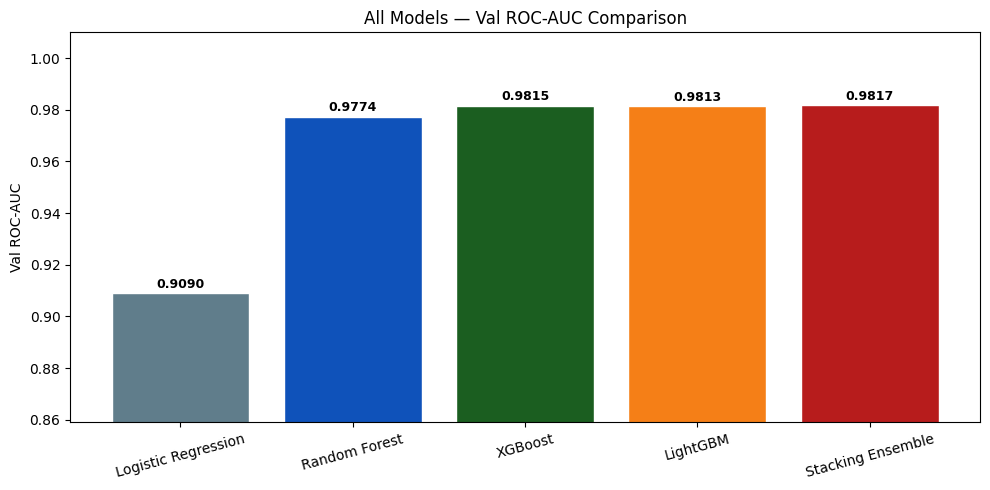

Saved: outputs/09_final_comparison.png


In [12]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#607D8B", "#0F52BA", "#1B5E20", "#F57F17", "#B71C1C"]
bars = ax.bar(comparison["Model"], comparison["Val ROC-AUC"],
              color=colors[:len(comparison)], edgecolor="white")
for bar, val in zip(bars, comparison["Val ROC-AUC"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            "%.4f" % val, ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Val ROC-AUC")
ax.set_title("All Models — Val ROC-AUC Comparison")
ax.set_ylim(comparison["Val ROC-AUC"].min() - 0.05, 1.01)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(OUTPUTS / "09_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/09_final_comparison.png")

## Section 4 — Select Final Model

In [13]:
# Map model name to the saved pkl file
MODEL_MAP = {
    "Logistic Regression": "lr_model.pkl",
    "Random Forest":        "rf_model.pkl",
    "XGBoost":              "xgb_model.pkl",
    "LightGBM":             "lgbm_model.pkl",
    "Stacking Ensemble":    None,   # saved fresh below
}

# Save stacking model
stacking_bundle = {
    "meta_learner": best_meta,
    "rf_full":      rf_full,
    "xgb_full":     xgb_full,
    "lgbm_full":    lgbm_full,
    "feature_cols": FEATURE_COLS,
    "meta_name":    meta_name,
}
joblib.dump(stacking_bundle, OUTPUTS / "stacking_model.pkl")
print("Saved: outputs/stacking_model.pkl")

# Select and copy final model
if recommended == "Stacking Ensemble":
    joblib.dump(stacking_bundle, OUTPUTS / "final_model.pkl")
    final_model_loaded = stacking_bundle
else:
    src = OUTPUTS / MODEL_MAP[recommended]
    shutil.copy(src, OUTPUTS / "final_model.pkl")
    final_model_loaded = joblib.load(OUTPUTS / "final_model.pkl")

final_val_auc = comparison.loc[comparison["Model"] == recommended, "Val ROC-AUC"].iloc[0]
(OUTPUTS / "final_model_name.txt").write_text(
    "final_model=%s\nval_roc_auc=%.4f\n" % (recommended, final_val_auc)
)

print()
print("=" * 55)
print("Final model selected : %s" % recommended)
print("Val ROC-AUC          : %.4f" % final_val_auc)
print("=" * 55)
print("Saved: outputs/final_model.pkl")
print("Saved: outputs/final_model_name.txt")

Saved: outputs/stacking_model.pkl



Final model selected : XGBoost
Val ROC-AUC          : 0.9815
Saved: outputs/final_model.pkl
Saved: outputs/final_model_name.txt
